In [158]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

from sklearn.linear_model import Lasso, Ridge, LassoCV, RidgeCV
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn import tree
from sklearn.utils import resample

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings('ignore')


from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import BaggingRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.base import clone


In [159]:
df = pd.read_csv('models/dataset_final.csv')

display(df.head(3))

,Unnamed: 0,zpid,address,price,beds,baths,area_sqft,latitude,longitude,status,...,state_name,county_lookup,state_median_housing_value,state_median_prop_tax_rate,med_prop_tax_paid,single_filer_rates,single_filer_brackets,married_filing_jointly_rates,married_filing_jointly_brackets,state_avg_median_income
0,0,17264897,"979 Kevin Ave, Redlands, CA 92373",447000,3.0,2.0,1300.0,34.040520,-117.186195,House for sale,...,California,San Bernardino County,481100.0,0.69,3293.5,9.0,72724.0,9.0,145448.0,98741.5
1,1,20021372,"13114 Addison St, Sherman Oaks, CA 91423",2795000,4.0,5.0,2900.0,34.160885,-118.418770,House for sale,...,California,Los Angeles County,481100.0,0.69,3293.5,9.0,72724.0,9.0,145448.0,98741.5
2,2,20009320,"6032 Goodland Ave, North Hollywood, CA 91606",1718000,4.0,3.0,3025.0,34.180450,-118.411280,House for sale,...,California,Los Angeles County,481100.0,0.69,3293.5,9.0,72724.0,9.0,145448.0,98741.5


##### Intercept Only Model

In [160]:
# setting response variable
y = df['price']

# setting an array of ones to same number of rows in the master dataset 
X = np.ones((len(df), 1))

# fitting the model with the intercept only
model = LinearRegression().fit(X, y)
print(f"Intercept: {model.intercept_}")

# validating 
intercept = df['price'].mean()
print(f"Correct Intercept: {intercept}")

Intercept: 1372109.4021894336
Correct Intercept: 1372109.4021894336


##### Lasso & Ridge Models

In [161]:
# Filtering the dataframe to only have houses that can  be purchased
print('======Before======')
print(df['status'].value_counts())

pre_status_drop = df['status'].shape[0]
print(f'There are {pre_status_drop} rows in the status column')

drop_vals = ['Foreclosure', 'Auction']
df_filtered = df[~df['status'].isin(drop_vals)].copy()

print()
print('======After======')
print(df_filtered['status'].value_counts())
# Checking how many null values 
df_filtered.isnull().sum()
# Using the median for null values in area_sqft
df_filtered["area_sqft"] = df_filtered["area_sqft"].fillna(
    df_filtered["area_sqft"].median()
)
# Only had 1 null in longitude and latitude so decided to drop it
df_filtered = df_filtered.dropna(subset=["latitude", "longitude"])
df_filtered.isnull().sum()

post_status_drop = df_filtered['status'].shape[0]
print(f'Number of rows removed: {pre_status_drop - post_status_drop}')
print(f'There are {post_status_drop} rows in the status column')

print()
print(f'Null values remaining: {df_filtered.isnull().sum()[df_filtered.isnull().sum() > 0]}')



======Before======
status
House for sale           1447
Active                    350
Coming soon               219
Condo for sale             18
Active Under Contract      14
Townhouse for sale         14
New construction           13
Foreclosure                11
For sale by owner           8
Auction                     3
Coming Soon                 3
New                         1
Name: count, dtype: int64
There are 2101 rows in the status column

======After======
status
House for sale           1447
Active                    350
Coming soon               219
Condo for sale             18
Townhouse for sale         14
Active Under Contract      14
New construction           13
For sale by owner           8
Coming Soon                 3
New                         1
Name: count, dtype: int64
Number of rows removed: 15
There are 2086 rows in the status column

Null values remaining: zestimate    1037
dtype: int64


In [162]:
df_filtered.describe()

,Unnamed: 0,zpid,price,beds,baths,area_sqft,latitude,longitude,days_on_zillow,zestimate,zipcode,state_median_housing_value,state_median_prop_tax_rate,med_prop_tax_paid,single_filer_rates,single_filer_brackets,married_filing_jointly_rates,married_filing_jointly_brackets,state_avg_median_income
count,2086.000000,2.086000e+03,2.086000e+03,2086.000000,2086.000000,2086.000000,2086.000000,2086.000000,2086.000000,1.049000e+03,2086.000000,2086.000000,2086.000000,2086.000000,2086.000000,2086.000000,2086.000000,2086.000000,2086.00000
mean,1083.254554,1.599796e+08,1.379320e+06,3.692234,2.939358,2718.970757,39.449264,-92.950196,23.569990,7.121868e+05,50797.402685,261450.167785,0.887876,2548.499760,4.724832,32133.702301,4.724832,52845.736817,88244.03104
std,627.826462,3.662249e+08,8.791477e+06,1.226880,1.694763,2805.578148,4.588989,16.053745,61.740531,1.566842e+06,30649.240055,106227.342123,0.506130,2011.530458,2.551160,33161.608139,2.551160,61693.602828,13391.64951
min,0.000000,8.239400e+04,3.550000e+04,1.000000,1.000000,572.000000,26.391940,-124.097000,-1.000000,2.920000e+04,1756.000000,134650.000000,0.280000,481.000000,0.000000,0.000000,0.000000,0.000000,65850.75000
25%,526.250000,2.290783e+07,3.382500e+05,3.000000,2.000000,1674.000000,36.001588,-105.073595,2.000000,3.468000e+05,25414.000000,169250.000000,0.520000,1134.000000,4.000000,0.000000,4.000000,0.000000,78990.25000
50%,1093.500000,5.321515e+07,4.950000e+05,4.000000,3.000000,2206.000000,39.601343,-90.639868,4.000000,4.905000e+05,55304.000000,231900.000000,0.690000,1888.000000,5.000000,26050.000000,5.000000,26050.000000,83007.25000
75%,1628.750000,1.149182e+08,7.600000e+05,4.000000,3.000000,2929.000000,42.769367,-78.822317,9.000000,7.355000e+05,78037.500000,335600.000000,1.070000,3293.500000,6.000000,60000.000000,6.000000,82500.000000,99511.75000
max,2158.000000,2.134250e+09,3.000000e+08,18.000000,27.000000,50000.000000,48.790657,-69.429490,745.000000,4.079420e+07,99362.000000,587550.000000,2.030000,8055.000000,9.000000,100000.000000,9.000000,200000.000000,114341.75000


In [163]:
#Trying to get rid of extreme outliers on both the low and high ends of prices

# Minimum should be $35,500 but this is left as a safety
df_filtered = df_filtered[df_filtered['price'] > 10000]

cap = df_filtered['price'].quantile(0.99)
print(f"Capping at: ${cap:,.0f}")
df_filtered = df_filtered[df_filtered['price'] <= cap]

print(f"Rows remaining: {len(df_filtered)}")
print(df_filtered['price'].describe())

Capping at: $22,560,000
Rows remaining: 2065
count    2.065000e+03
mean     7.704434e+05
std      1.470751e+06
min      3.550000e+04
25%      3.350000e+05
50%      4.899000e+05
75%      7.500000e+05
max      2.250000e+07
Name: price, dtype: float64


In [164]:
'''
List of Columns for feature engineering
Index(['Unnamed: 0', 'zpid', 'address', 'price', 'beds', 'baths', 'area_sqft',
       'latitude', 'longitude', 'status', 'home_type', 'days_on_zillow',
       'zestimate', 'detail_url', 'has_open_house', 'is_featured',
       'street_add', 'city', 'state_zipcode', 'state_code', 'zipcode',
       'state_name', 'county_lookup', 'state_median_housing_value',
       'state_median_prop_tax_rate', 'med_prop_tax_paid', 'single_filer_rates',
       'single_filer_brackets', 'married_filing_jointly_rates',
       'married_filing_jointly_brackets', 'state_avg_median_income'],
      dtype='object')
'''

"\nList of Columns for feature engineering\nIndex(['Unnamed: 0', 'zpid', 'address', 'price', 'beds', 'baths', 'area_sqft',\n       'latitude', 'longitude', 'status', 'home_type', 'days_on_zillow',\n       'zestimate', 'detail_url', 'has_open_house', 'is_featured',\n       'street_add', 'city', 'state_zipcode', 'state_code', 'zipcode',\n       'state_name', 'county_lookup', 'state_median_housing_value',\n       'state_median_prop_tax_rate', 'med_prop_tax_paid', 'single_filer_rates',\n       'single_filer_brackets', 'married_filing_jointly_rates',\n       'married_filing_jointly_brackets', 'state_avg_median_income'],\n      dtype='object')\n"

**We elected to use log during training to improve relative error scaling in comparison to absolute error scaling**

**Ex. $2m home with 200k error is 10% off while $500k home with 200k error is 40% off**

In [165]:
# Dropping columns that are redundant or unhelpful
# Not sure if I should include zestimate, is_featured, and has_opened_house
# Also not sure about zipcode, city, and state name because they are string and if you one hot encode it would be a lot of columns
features = ['beds', 'baths', 'area_sqft', 'latitude', 'longitude', 'home_type', 
            'days_on_zillow', 'state_median_housing_value', 'state_median_prop_tax_rate', 
            'med_prop_tax_paid', 'state_code']
target = 'price'

RANDOM_STATE = 42

X = df_filtered[features]

# Adding dummy variables for one-hot encoding
X = pd.get_dummies(X, columns=["home_type", "state_code"], drop_first=True)

# Changing the target outcome to be between 0 and 1
y = np.log(df_filtered[target])

# Splitting the data with 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [180]:
# Confirming no underlying issues with the train/test datasets post-cleaning
train_df = X_train.copy()
test_df = X_test.copy()

train_df["price"] = y_train
test_df["price"] = y_test

print("=====TRAIN SUMMARY=====")
display(train_df.describe())

print("=====TEST SUMMARY=====")
display(test_df.describe())

=====TRAIN SUMMARY=====


,beds,baths,area_sqft,latitude,longitude,days_on_zillow,state_median_housing_value,state_median_prop_tax_rate,med_prop_tax_paid,price
count,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000,1652.000000
mean,3.637409,2.838983,2529.863801,39.464291,-92.728468,21.327482,261310.169492,0.894192,2571.974879,13.156393
std,1.076653,1.245019,1705.541291,4.600150,16.017718,55.786865,105585.079224,0.506576,2028.996455,0.721837
min,1.000000,1.000000,572.000000,26.391940,-124.039010,-1.000000,134650.000000,0.280000,481.000000,10.477288
25%,3.000000,2.000000,1670.000000,36.021751,-105.049796,2.000000,169250.000000,0.520000,1134.000000,12.721886
50%,4.000000,3.000000,2206.000000,39.642481,-90.542760,4.000000,231900.000000,0.690000,1888.000000,13.101957
75%,4.000000,3.000000,2886.500000,42.801018,-78.606965,9.000000,335600.000000,1.070000,3293.500000,13.527828
max,17.000000,14.000000,29087.000000,48.790657,-69.429490,745.000000,587550.000000,2.030000,8055.000000,16.929026


=====TEST SUMMARY=====


,beds,baths,area_sqft,latitude,longitude,days_on_zillow,state_median_housing_value,state_median_prop_tax_rate,med_prop_tax_paid,price
count,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000,413.000000
mean,3.690073,2.877724,2563.815981,39.385927,-93.539261,22.871671,260734.019370,0.863765,2453.645278,13.177695
std,1.106391,1.405671,1639.820512,4.512633,16.096671,58.668441,109029.783714,0.505788,1965.765368,0.776309
min,1.000000,1.000000,634.000000,29.214384,-124.097000,0.000000,146400.000000,0.280000,481.000000,11.225243
25%,3.000000,2.000000,1658.000000,35.923950,-105.070450,2.000000,169250.000000,0.460000,921.000000,12.718597
50%,4.000000,3.000000,2206.000000,39.526510,-92.257900,4.000000,204700.000000,0.690000,1888.000000,13.093964
75%,4.000000,3.000000,2904.000000,42.028996,-80.871550,10.000000,390250.000000,1.070000,3293.500000,13.527827
max,10.000000,12.000000,16936.000000,48.719875,-72.035515,572.000000,481100.000000,2.030000,8055.000000,16.810993


**The previous output (directly above) shows the expected summary statistics and similar data for the train/test splits**

In [167]:
# Scaling the data
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

alphas = np.logspace(-3, 6, 200)
alphas

ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train_sc, y_train)

print("Best alpha (Ridge):", ridge.alpha_)

lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso.fit(X_train_sc, y_train)

print("Best alpha (Lasso):", lasso.alpha_)

Best alpha (Ridge): 69.0551352016233
Best alpha (Lasso): 0.002072921779595372


In [ ]:
# NEW
for name, model in [('Lasso', lasso), ('Ridge', ridge)]:
    y_pred_test_log = model.predict(X_test_sc)
    y_pred_train_log = model.predict(X_train_sc)

    # log metrics
    mse_test_log  = mean_squared_error(y_test, y_pred_test_log)
    mse_train_log  = mean_squared_error(y_train, y_pred_train_log)

    mae_test_log = mean_absolute_error(y_test, y_pred_test_log)
    mae_train_log = mean_absolute_error(y_train, y_pred_train_log)

    r2_test   = r2_score(y_test, y_pred_test_log)
    r2_train   = r2_score(y_train, y_pred_train_log)

    # convert log metrics back to dollars
    y_test_price = np.exp(y_test)
    y_train_price = np.exp(y_train)

    y_pred_test_price = np.exp(y_pred_test_log)
    y_pred_train_price = np.exp(y_pred_train_log)

    # dollar-space metrics
    mse_test_price = mean_squared_error(y_test_price, y_pred_test_price)
    mse_train_price = mean_squared_error(y_train_price, y_pred_train_price)

    mae_test_price = mean_absolute_error(y_test_price, y_pred_test_price)
    mae_train_price = mean_absolute_error(y_train_price, y_pred_train_price)

    r2_test_price = r2_score(y_test_price, y_pred_test_price)
    r2_train_price = r2_score(y_train_price, y_pred_train_price)

    print(f"\n{name}")

    print('Log Metrics:')
    print(f"  Train MSE: {mse_train_log:.4f} | Test MSE: {mse_test_log:.4f}")
    print(f"  Train MAE: {mae_train_log:.4f} | Test MAE: {mae_test_log:.4f}")
    print(f"  Train R2:  {r2_train:.4f} | Test R2:  {r2_test:.4f}")

    print('Dollar Metrics:')
    print(f"    Train MSE: ${mse_train_price:,.2f} | Test MSE: ${mse_test_price:,.2f}")
    print(f"    Train MAE: ${mae_train_price:,.2f} | Test MAE: ${mae_test_price:,.2f}")
    print(f"    Train R2:  {r2_train_price:.4f} | Test R2:  {r2_test_price:.4f}")

# Finding out which coefficients had the bigger impact
feature_names = X.columns
lasso_coefs = pd.Series(lasso.coef_, index=feature_names)

lasso_sorted = lasso_coefs.reindex(
    lasso_coefs.abs().sort_values(ascending=False).index
)
ridge_coefs = pd.Series(ridge.coef_, index=feature_names)

ridge_sorted = ridge_coefs.reindex(
    ridge_coefs.abs().sort_values(ascending=False).index
)



Lasso
Log Metrics:
  Train MSE: 0.2060 | Test MSE: 0.2231
  Train MAE: 0.3299 | Test MAE: 0.3426
  Train R2:  0.6045 | Test R2:  0.6289
Dollar Metrics:
    Train MSE: $5,641,193,274,178.31 | Test MSE: $1,617,234,868,085.58
    Train MAE: $346,617.27 | Test MAE: $331,796.68
    Train R2:  -1.6108 | Test R2:  0.2529

Ridge
Log Metrics:
  Train MSE: 0.2064 | Test MSE: 0.2246
  Train MAE: 0.3295 | Test MAE: 0.3436
  Train R2:  0.6036 | Test R2:  0.6265
Dollar Metrics:
    Train MSE: $5,255,871,873,047.53 | Test MSE: $1,575,309,786,123.77
    Train MAE: $343,767.53 | Test MAE: $332,202.56
    Train R2:  -1.4324 | Test R2:  0.2723


In [169]:
# original
for name, model in [('Lasso', lasso), ('Ridge', ridge)]:
    y_pred_test = model.predict(X_test_sc)
    y_pred_train = model.predict(X_train_sc)
    mse_test  = mean_squared_error(y_test, y_pred_test)
    mse_train  = mean_squared_error(y_train, y_pred_train)
    rmse_test = np.sqrt(mse_test)
    rmse_train = np.sqrt(mse_train)
    r2_test   = r2_score(y_test, y_pred_test)
    r2_train   = r2_score(y_train, y_pred_train)
    print(f"\n{name}")
    print(f"  Train MSE: {mse_train:.4f} | Test MSE: {mse_test:.4f}")
    print(f"  Train RMSE: {rmse_train:.4f} | Test RMSE: {rmse_test:.4f}")
    print(f"  Train R2:  {r2_train:.4f} | Test R2:  {r2_test:.4f}")

# Finding out which coefficients had the bigger impact
feature_names = X.columns
lasso_coefs = pd.Series(lasso.coef_, index=feature_names)

lasso_sorted = lasso_coefs.reindex(
    lasso_coefs.abs().sort_values(ascending=False).index
)
ridge_coefs = pd.Series(ridge.coef_, index=feature_names)

ridge_sorted = ridge_coefs.reindex(
    ridge_coefs.abs().sort_values(ascending=False).index
)


Lasso
  Train MSE: 0.2060 | Test MSE: 0.2231
  Train RMSE: 0.4538 | Test RMSE: 0.4723
  Train R2:  0.6045 | Test R2:  0.6289

Ridge
  Train MSE: 0.2064 | Test MSE: 0.2246
  Train RMSE: 0.4543 | Test RMSE: 0.4739
  Train R2:  0.6036 | Test R2:  0.6265


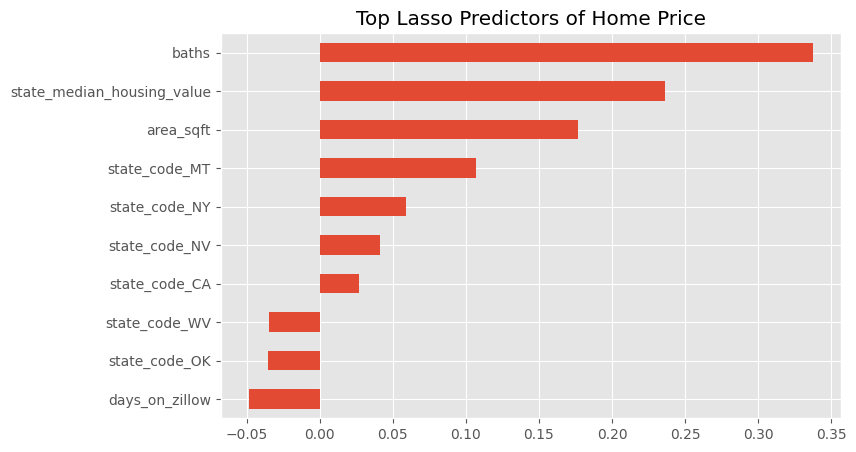

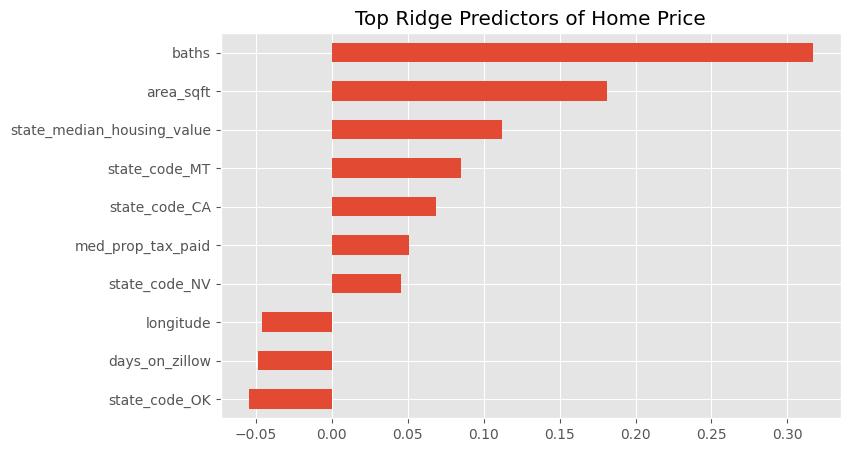

In [170]:
# Visualizations for Lasso coefficients 
top_lasso = lasso_sorted
top_10_lasso = top_lasso.reindex(top_lasso.abs().sort_values(ascending=False).head(10).index)

plt.figure(figsize=(8,5))
top_10_lasso.sort_values().plot(kind="barh")
plt.title("Top Lasso Predictors of Home Price")
plt.show()

# Visualizations for Ridge (probably not super necessary but just good to compare to )
top_ridge = ridge_sorted
top_10_ridge = ridge_sorted.reindex(top_ridge.abs().sort_values(ascending=False).head(10).index)

plt.figure(figsize=(8,5))
top_10_ridge.sort_values().plot(kind="barh")
plt.title("Top Ridge Predictors of Home Price")
plt.show()

#### Decision Trees

Number of Features: 43
Best Decision Tree Parameters: {'ccp_alpha': 0.001, 'max_depth': 9, 'min_samples_leaf': 8}
Best CV MSE (log price) 0.23329968609129784


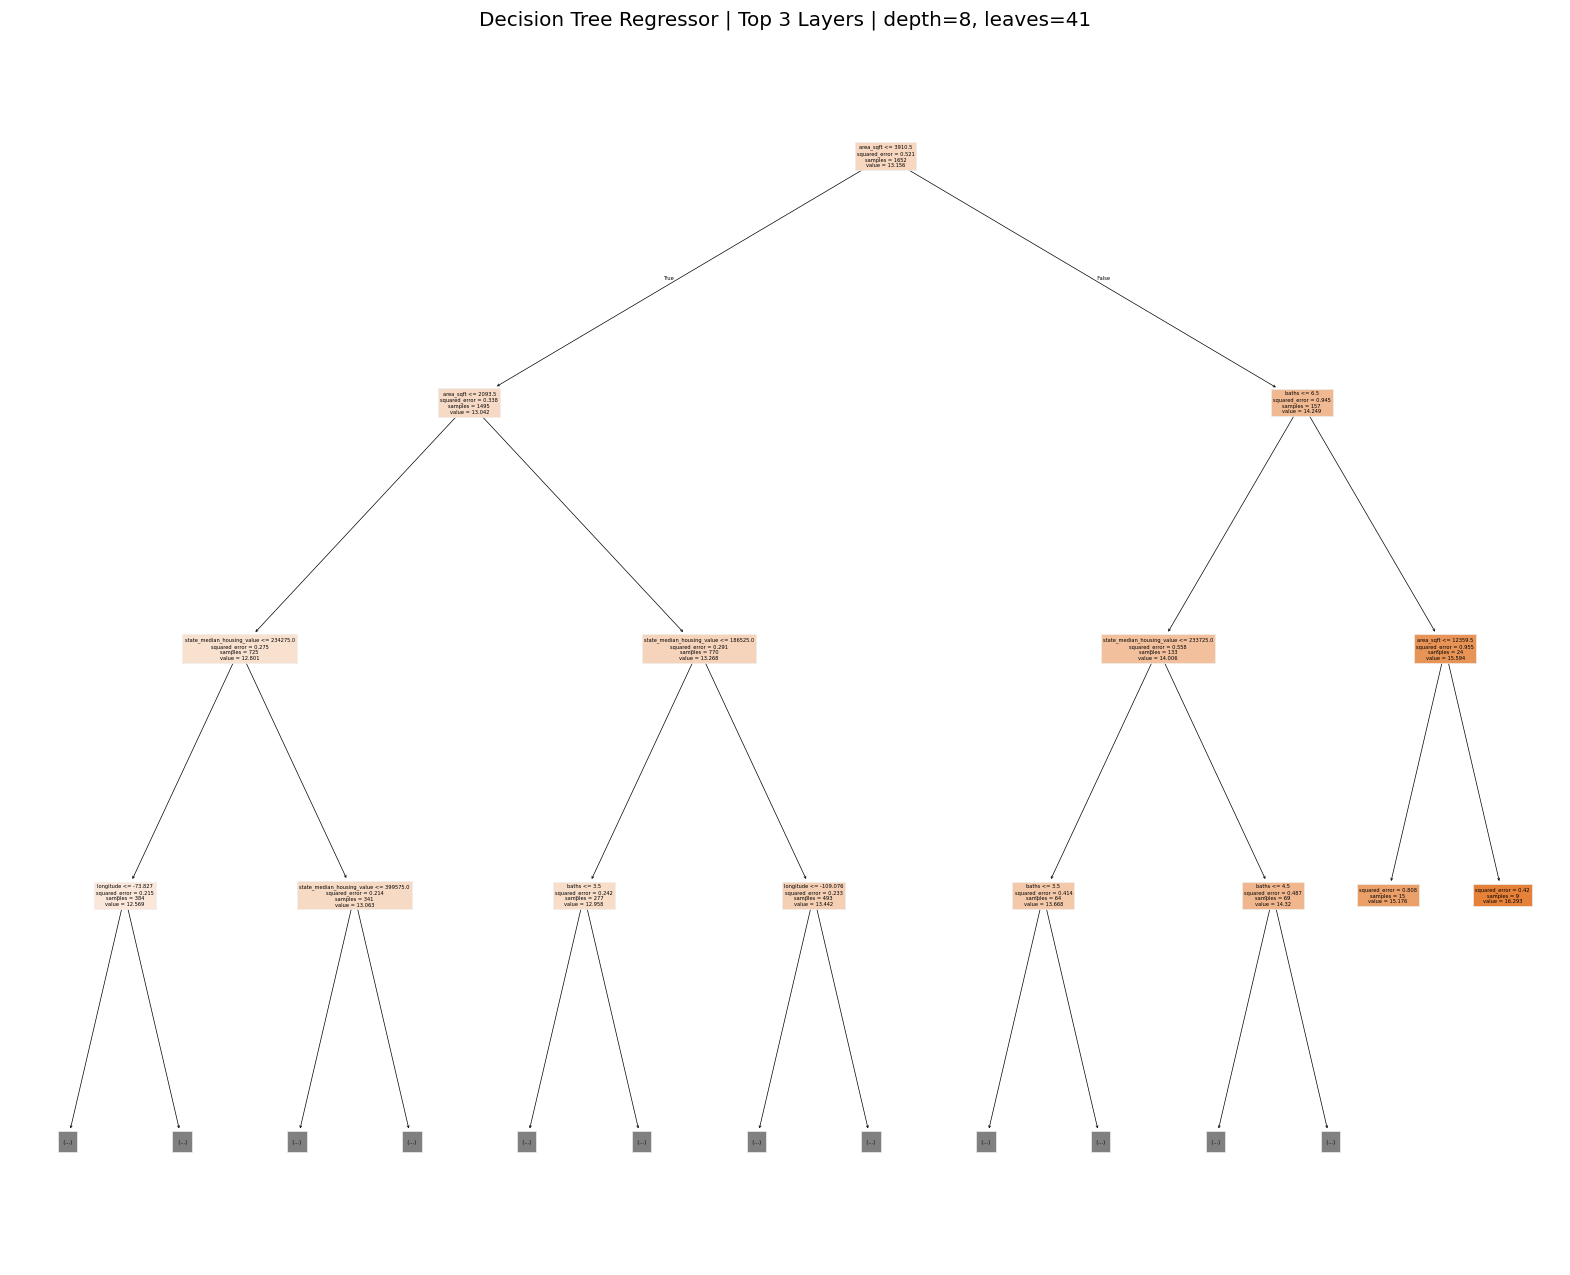

In [171]:
# copy predictors from X_train

random_state = RANDOM_STATE
PREDICTORS = list(X_train.columns)
print(f'Number of Features: {len(PREDICTORS)}')

# param sweep for dt model
# if not included, train MSE/MAE overfits to $0
dt_param_grid = {
    'max_depth': [1, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, None],
    'min_samples_leaf': [1, 2, 3, 5, 8, 10, 12, 15, 18, 20, 25],
    'ccp_alpha': [0, 0.00001, 0.00005, 0.0001, 0.0005, 0.001, 0.0025, 0.005, 0.01, 0.025, 0.050, 0.10],
}

dt_grid_search = (
    GridSearchCV(
        estimator = DecisionTreeRegressor(random_state=random_state),
        param_grid = dt_param_grid,
        cv = 5,
        scoring = 'neg_mean_squared_error',
        n_jobs = 1
    )
)

dt_grid_search.fit(X_train[PREDICTORS], y_train)

# best model
dt_best_model = dt_grid_search.best_estimator_
# best params
dt_best_params = dt_grid_search.best_params_
# cv score 
dt_best_cv = dt_grid_search.best_score_

print(f'Best Decision Tree Parameters: {dt_best_params}')
print(f'Best CV MSE (log price) {-dt_best_cv}')


fig = plt.figure(figsize=(20,16))
tree.plot_tree(dt_best_model, feature_names=PREDICTORS, filled=True, max_depth=3)
plt.title(f'Decision Tree Regressor | Top 3 Layers | depth={dt_best_model.get_depth()}, leaves={dt_best_model.get_n_leaves()}')
plt.show()

In [172]:
# Same metrics, now using dt_best instead of dt_single
y_pred_train_dt = dt_best_model.predict(X_train[PREDICTORS])
y_pred_test_dt  = dt_best_model.predict(X_test[PREDICTORS])

print("===== Decision Tree Metrics =====")
print(f"Train MSE: {mean_squared_error(y_train, y_pred_train_dt):.4f}")
print(f"Test  MSE: {mean_squared_error(y_test,  y_pred_test_dt):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train_dt):.4f}")
print(f"Test  MAE: {mean_absolute_error(y_test,  y_pred_test_dt):.4f}")
print(f"Train R^2: {r2_score(y_train, y_pred_train_dt):.4f}")
print(f"Test  R^2: {r2_score(y_test,  y_pred_test_dt):.4f}")

dollar_mae_train_dt = mean_absolute_error(np.exp(y_train), np.exp(y_pred_train_dt))
dollar_mae_test_dt  = mean_absolute_error(np.exp(y_test),  np.exp(y_pred_test_dt))
print(f"MAE in Dollars (Train): ${dollar_mae_train_dt:,.2f}")
print(f"MAE in Dollars (Test):  ${dollar_mae_test_dt:,.2f}")

===== Decision Tree Metrics =====
Train MSE: 0.1660
Test  MSE: 0.2765
Train MAE: 0.3027
Test  MAE: 0.3777
Train R^2: 0.6813
Test  R^2: 0.5401
MAE in Dollars (Train): $270,184.89
MAE in Dollars (Test):  $361,838.10


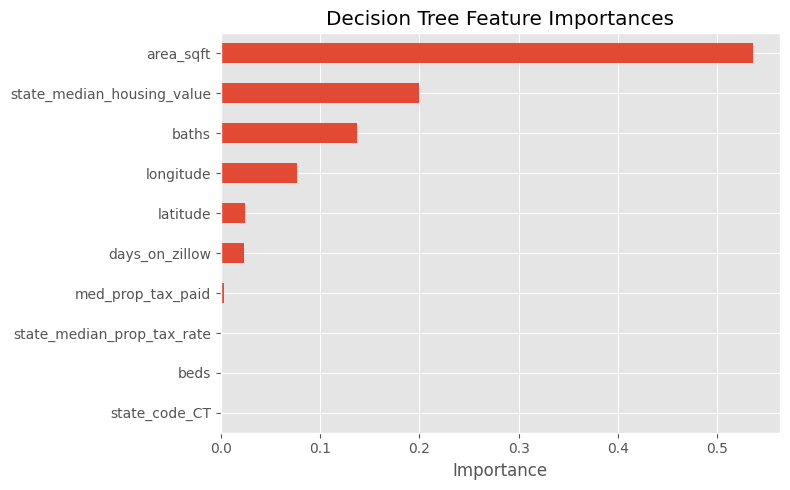

In [173]:
dt_importance = (
    pd.Series(dt_best_model.feature_importances_, index = PREDICTORS).sort_values(ascending=True) )

plt.figure(figsize=(8, 5))
dt_importance.reindex(
    dt_importance.sort_values(ascending=False).head(10).index
).sort_values().plot(kind='barh').plot(kind='barh')
plt.title("Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [174]:
# Random Forest Regressor Modeling

# RandomForestRegressor already does bootstrap sampling + feature subsetting per split.
# max_features='sqrt' matches what you were doing manually. oob_score gives a free
# validation estimate without touching the test set.

rf = (
    RandomForestRegressor(
        n_estimators = 10000,
        max_features = 'sqrt',
        min_samples_leaf = 2,
        bootstrap = True,
        oob_score = True, # 'out-of-bag' score
        n_jobs = 1,
        random_state = random_state
    )
)

rf.fit(X_train, y_train)

print("===== Random Forest Tree Information =====")
print(f'Number of Trees: {rf.n_estimators}')
print(f'Max features per split: {rf.max_features}')
print(f"OOB R^2: {rf.oob_score_:.4f}")

===== Random Forest Tree Information =====
Number of Trees: 10000
Max features per split: sqrt
OOB R^2: 0.6444


In [175]:
y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf  = rf.predict(X_test)

print('===== Random Forest Metrics =====')
print()

print('Log Metrics:')
print(f'Train MSE: {mean_squared_error(y_train, y_pred_train_rf):.4f}')
print(f'Test  MSE: {mean_squared_error(y_test,  y_pred_test_rf):.4f}')
print(f'Train MAE: {mean_absolute_error(y_train, y_pred_train_rf):.4f}')
print(f'Test  MAE: {mean_absolute_error(y_test,  y_pred_test_rf):.4f}')
print(f'Train R^2: {r2_score(y_train, y_pred_train_rf):.4f}')
print(f'Test  R^2: {r2_score(y_test,  y_pred_test_rf):.4f}')

dollar_mae_train_rf = mean_absolute_error(np.exp(y_train), np.exp(y_pred_train_rf))
dollar_mae_test_rf  = mean_absolute_error(np.exp(y_test),  np.exp(y_pred_test_rf))

print()
print('Dollar Metrics:')
print(f'MAE in Dollars (Train): ${dollar_mae_train_rf:,.2f}')
print(f'MAE in Dollars (Test):  ${dollar_mae_test_rf:,.2f}')

===== Random Forest Metrics =====

Log Metrics:
Train MSE: 0.0870
Test  MSE: 0.2179
Train MAE: 0.2083
Test  MAE: 0.3255
Train R^2: 0.8329
Test  R^2: 0.6376

Dollar Metrics:
MAE in Dollars (Train): $213,938.46
MAE in Dollars (Test):  $323,158.73


In [176]:
# Tree preds running loop for plot

# number of trees
n_trees = len(rf.estimators_)

# create arrays filled with 0's to start
mse_train_seq_rf = np.zeros(n_trees)
mse_test_seq_rf  = np.zeros(n_trees)

sum_train = np.zeros(len(X_train))
sum_test  = np.zeros(len(X_test))

for b, tree_b in enumerate(rf.estimators_):
    sum_train += tree_b.predict(X_train)
    sum_test  += tree_b.predict(X_test)
    mse_train_seq_rf[b] = mean_squared_error(y_train, sum_train / (b + 1))
    mse_test_seq_rf[b]  = mean_squared_error(y_test,  sum_test  / (b + 1))

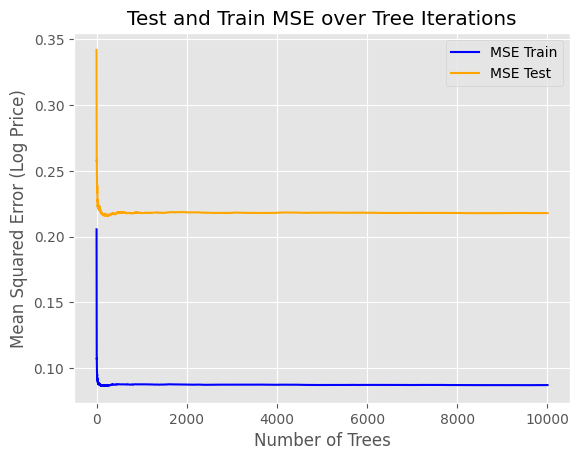

In [177]:
plt.plot(range(1, n_trees + 1), mse_train_seq_rf, label='MSE Train', c='blue')
plt.plot(range(1, n_trees + 1), mse_test_seq_rf,  label='MSE Test',  c='orange')
plt.xlabel('Number of Trees')
plt.ylabel('Mean Squared Error (Log Price)')
plt.legend()
plt.title("Test and Train MSE over Tree Iterations")
plt.show()

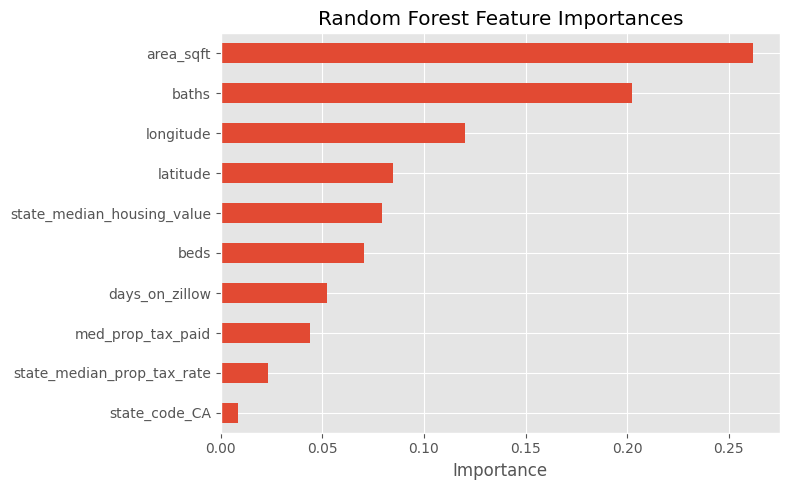

In [178]:
rf_importance = (
    pd.Series(rf.feature_importances_, index=PREDICTORS).sort_values(ascending=True) )


plt.figure(figsize=(8, 5))
rf_importance.reindex(
    rf_importance.sort_values(ascending=False).head(10).index
).sort_values().plot(kind='barh').plot(kind='barh')
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#### Bagging & Boosting

##### Neural Network